In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [40]:
data = pd.read_csv("H:\Datensätze\Portfolio_Insights\Cleaned Global Video Game Sales\cleaned_global_video_game_sales.csv")

<>:1: SyntaxWarning:

invalid escape sequence '\D'

<>:1: SyntaxWarning:

invalid escape sequence '\D'

C:\Users\kasum\AppData\Local\Temp\ipykernel_19364\3598835436.py:1: SyntaxWarning:

invalid escape sequence '\D'



In [41]:
data.head(8)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon RedPokemon Blue,GB,1996,Role Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02


In [42]:
data.isnull()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
11465,False,False,False,False,False,False,False,False,False,False,False
11466,False,False,False,False,False,False,False,False,False,False,False
11467,False,False,False,False,False,False,False,False,False,False,False
11468,False,False,False,False,False,False,False,False,False,False,False


In [43]:
data.head(8)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon RedPokemon Blue,GB,1996,Role Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02


In [44]:
#encoding
data['Platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'XThreeSixZero', 'PSThree', 'PSTow',
       'SNES', 'GBA', 'ThreeDS', 'PSFour', 'NSixFour', 'PS', 'XB', 'PC',
       'TowSixZeroZero', 'PSP', 'GC', 'WiiU', 'GEN', 'XOne', 'DC', 'SAT',
       'PSV', 'SCD', 'WS', 'NG', 'TGOneSix', 'ThreeDO', 'GG', 'PCFX'],
      dtype=object)

Häufigkeit der Jahre:
Year
0       165
1980      8
1981     43
1982     33
1983     16
1984     12
1985     13
1986     21
1987     15
1988     11
1989     14
1990     14
1991     40
1992     37
1993     57
1994    111
1995    200
1996    247
1997    265
1998    347
1999    291
2000    297
2001    410
2002    565
2003    485
2004    520
2005    615
2006    722
2007    835
2008    985
2009    959
2010    859
2011    746
2012    407
2013    296
2014    279
2015    333
2016    194
2017      2
2020      1
Name: count, dtype: int64


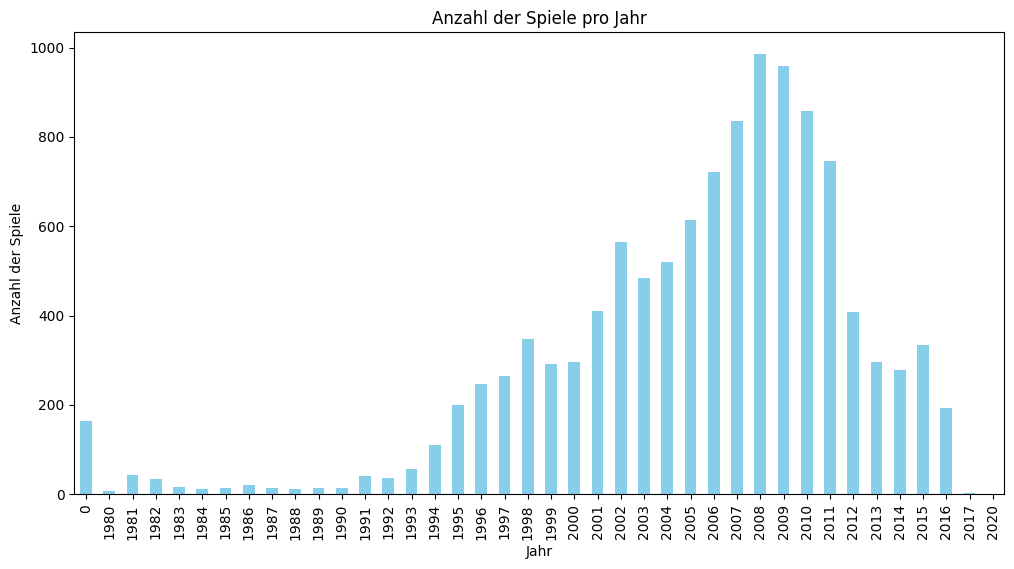

In [45]:
# Prüfen, ob die 'Year'-Spalte existiert
if 'Year' in data.columns:
    # Jahre zählen
    jahr_counts = data['Year'].value_counts().sort_index()  # sortiert nach Jahr

    print("Häufigkeit der Jahre:")
    print(jahr_counts)

    # Balkendiagramm erstellen
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,6))
    jahr_counts.plot(kind='bar', color='skyblue')
    plt.xlabel("Jahr")
    plt.ylabel("Anzahl der Spiele")
    plt.title("Anzahl der Spiele pro Jahr")
    plt.show()
else:
    print("Spalte 'Year' existiert nicht im DataFrame.")

Häufigkeit der Spiele pro Jahr und Plattform:
Platform  DC   DS  GB  GBA  GC  GEN  GG  NES  NG  NSixFour  ...  TGOneSix  \
Year                                                        ...             
0          0   24   1   10   5    0   0    0   0         1  ...         0   
1980       0    0   0    0   0    0   0    0   0         0  ...         0   
1981       0    0   0    0   0    0   0    0   0         0  ...         0   
1982       0    0   0    0   0    0   0    0   0         0  ...         0   
1983       0    0   0    0   0    0   0    5   0         0  ...         0   
1984       0    0   0    0   0    0   0   11   0         0  ...         0   
1985       0    1   0    0   0    0   0   10   0         0  ...         0   
1986       0    0   0    0   0    0   0   19   0         0  ...         0   
1987       0    0   0    0   0    0   0   10   0         0  ...         0   
1988       0    0   0    0   0    0   0    9   0         0  ...         0   
1989       0    0   7    0   0

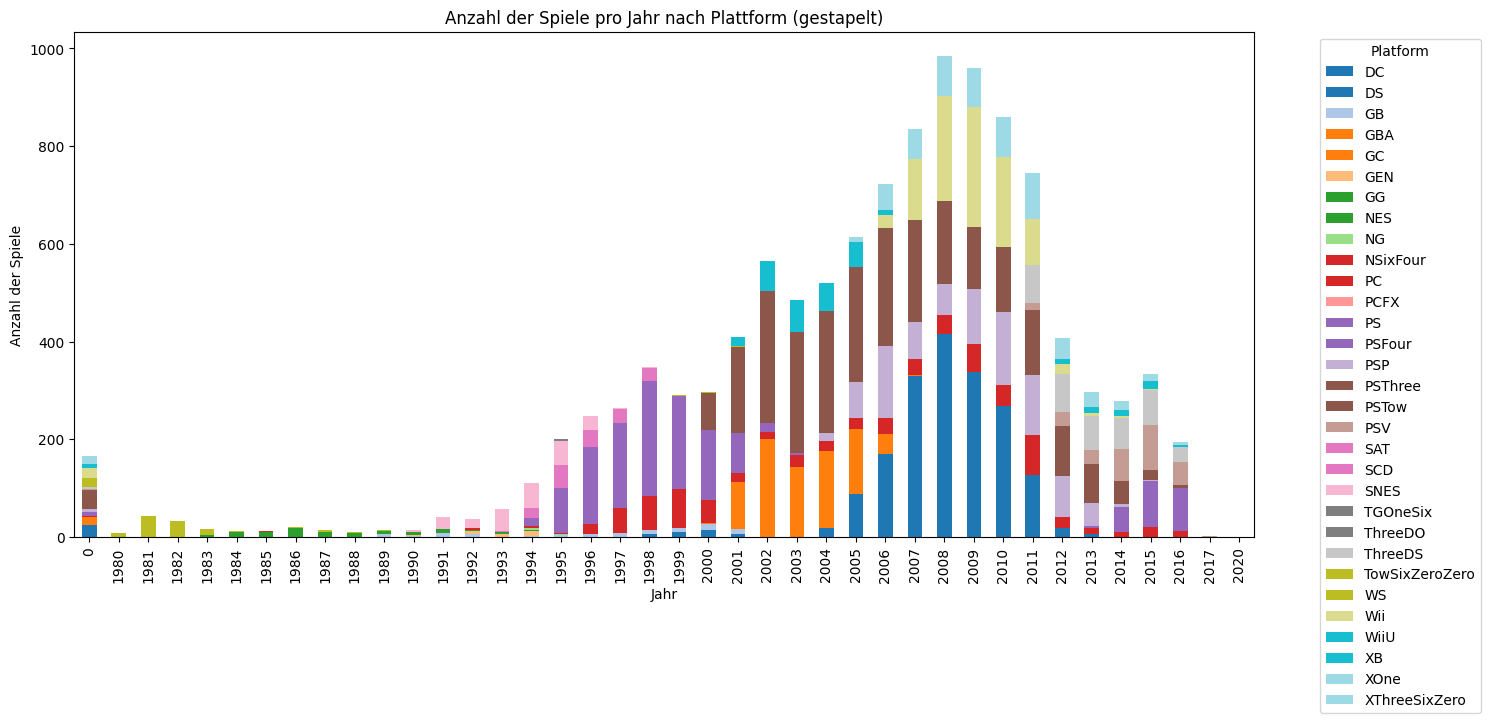

In [46]:
# Prüfen, ob 'Year' und 'Platform' existieren
if 'Year' in data.columns and 'Platform' in data.columns:
    # Gruppieren nach Year und Platform, dann zählen
    platform_year_counts = data.groupby(['Year', 'Platform']).size().unstack(fill_value=0)

    print("Häufigkeit der Spiele pro Jahr und Plattform:")
    print(platform_year_counts)

    # Balkendiagramm: jedes Jahr, gestapelt nach Plattform
    import matplotlib.pyplot as plt

    platform_year_counts.plot(kind='bar', stacked=True, figsize=(15,7), colormap='tab20')
    plt.xlabel("Jahr")
    plt.ylabel("Anzahl der Spiele")
    plt.title("Anzahl der Spiele pro Jahr nach Plattform (gestapelt)")
    plt.legend(title="Platform", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Spalten 'Year' oder 'Platform' fehlen im DataFrame.")

In [47]:
# Alle Zeilen, bei denen Year == 0 oder NaN
fehlerhafte_jahre = data[data['Year'] == 0]
print("Fehlerhafte Einträge (Year=0):")
print(fehlerhafte_jahre[['Name','Platform','Year']])

Fehlerhafte Einträge (Year=0):
                                      Name        Platform  Year
159             Madden NFL TwoZeroZeroFour           PSTow     0
325            FIFA Soccer TwoZeroZeroFour           PSTow     0
406    wwe Smackdown vs Raw TwoZeroZeroSix           PSTow     0
522                         Space Invaders  TowSixZeroZero     0
537                              Rock Band   XThreeSixZero     0
...                                    ...             ...   ...
11090          Aquaman Battle for Atlantis              XB     0
11182      Homeworld Remastered Collection              PC     0
11184                               Shorts              DS     0
11220           Agarest Senki Reappearance         PSThree     0
11309           Hakuouki Shinsengumi Kitan         PSThree     0

[165 rows x 3 columns]


In [48]:
# Year = 0 ersetzen durch NaN, damit wir sie sauber bearbeiten
data['Year'] = data['Year'].replace(0, pd.NA)

# Funktion: fehlende Year anhand der häufigsten Year der Platform füllen
def fill_year(row):
    if pd.isna(row['Year']):
        # Häufigstes Jahr auf dieser Platform
        modus = data[data['Platform'] == row['Platform']]['Year'].mode()
        if len(modus) > 0:
            return modus[0]  # ersten Wert des Modus verwenden
        else:
            return pd.NA
    else:
        return row['Year']

data['Year'] = data.apply(fill_year, axis=1)

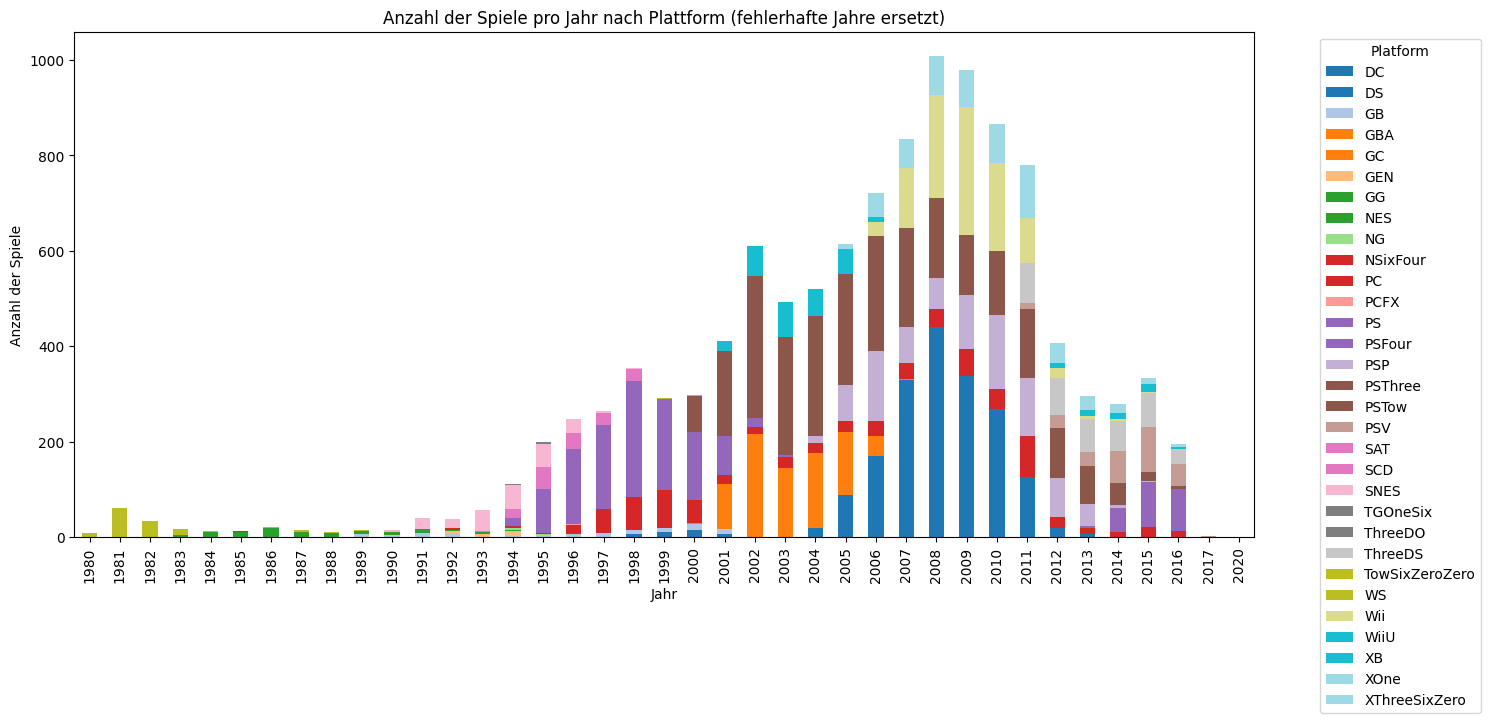

In [49]:
# Gruppieren nach Year und Platform
platform_year_counts = data.groupby(['Year','Platform']).size().unstack(fill_value=0)

# Gestapeltes Balkendiagramm
import matplotlib.pyplot as plt

platform_year_counts.plot(kind='bar', stacked=True, figsize=(15,7), colormap='tab20')
plt.xlabel("Jahr")
plt.ylabel("Anzahl der Spiele")
plt.title("Anzahl der Spiele pro Jahr nach Plattform (fehlerhafte Jahre ersetzt)")
plt.legend(title="Platform", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

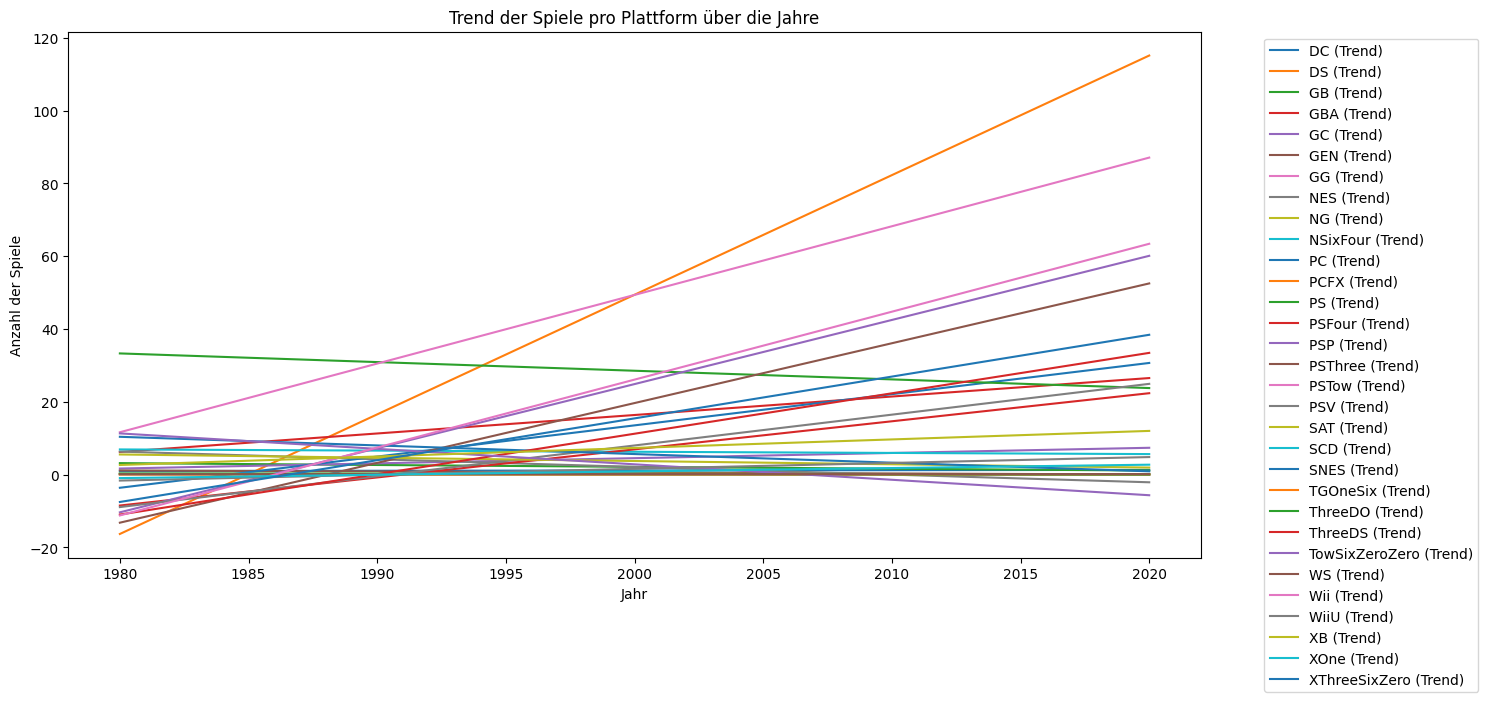

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Prüfen, ob 'Year' und 'Platform' vorhanden sind
if 'Year' in data.columns and 'Platform' in data.columns:
    # Year=0 durch NaN ersetzen und ggf. vorher schon repariert
    data['Year'] = data['Year'].replace(0, pd.NA)

    # Gruppieren nach Year und Platform
    platform_year_counts = data.groupby(['Year','Platform']).size().unstack(fill_value=0)

    plt.figure(figsize=(15,7))

    for plat in platform_year_counts.columns:
        y = platform_year_counts[plat].values
        x = platform_year_counts.index.values.astype(int)  # Jahre als Zahlen
        if np.sum(y) == 0:
            continue  # Plattform ohne Daten überspringen
        # Lineare Regression (Trendlinie)
        coef = np.polyfit(x, y, 1)  # Grad 1 → linearer Trend
        trend = np.poly1d(coef)
        
        # Trendlinie zeichnen
        plt.plot(x, trend(x), label=f"{plat} (Trend)")

    plt.xlabel("Jahr")
    plt.ylabel("Anzahl der Spiele")
    plt.title("Trend der Spiele pro Plattform über die Jahre")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Spalten 'Year' oder 'Platform' fehlen im DataFrame.")

In [51]:
import plotly.io as pio
pio.renderers.default = "browser"

import pandas as pd
import plotly.express as px

# Gruppieren
platform_year_counts = data.groupby(['Year','Platform']).size().reset_index(name='Count')

# Interaktiver Plot
fig = px.line(
    platform_year_counts,
    x="Year",
    y="Count",
    color="Platform",
    title="Trend der Spiele pro Plattform über die Jahre"
)

fig.show()

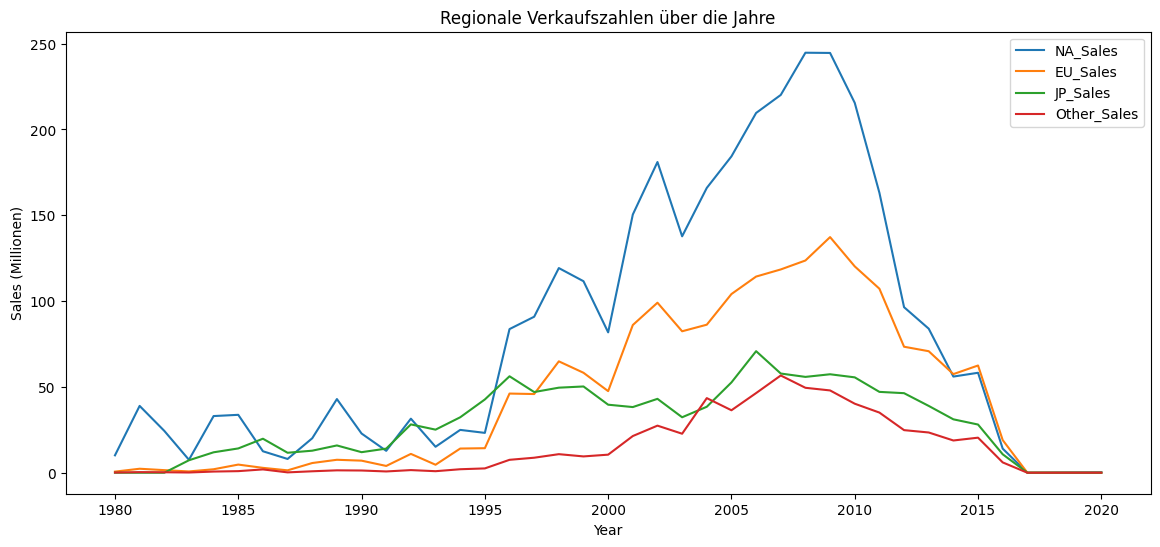

In [52]:
#Regionsales at Years
region_year = data.groupby("Year")[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()

region_year.plot(figsize=(14,6))
plt.title("Regionale Verkaufszahlen über die Jahre")
plt.ylabel("Sales (Millionen)")
plt.show()

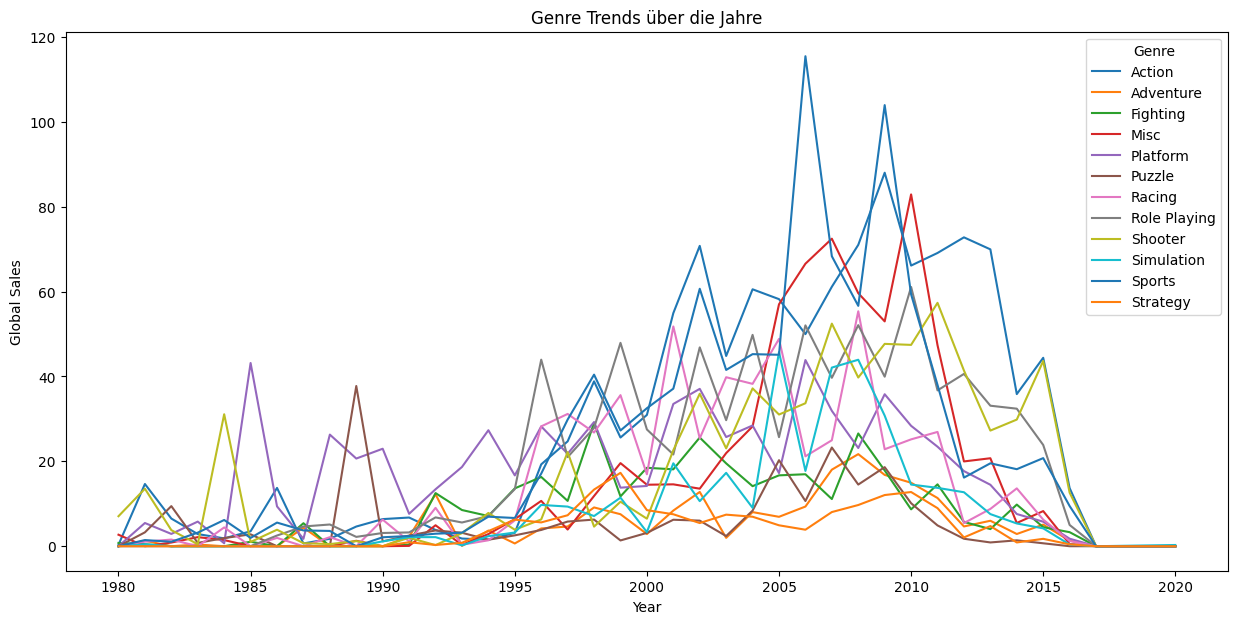

In [53]:
#Genre Trend at Years
genre_year = data.groupby(["Year","Genre"])["Global_Sales"].sum().unstack(fill_value=0)

genre_year.plot(figsize=(15,7))
plt.title("Genre Trends über die Jahre")
plt.ylabel("Global Sales")
plt.show()

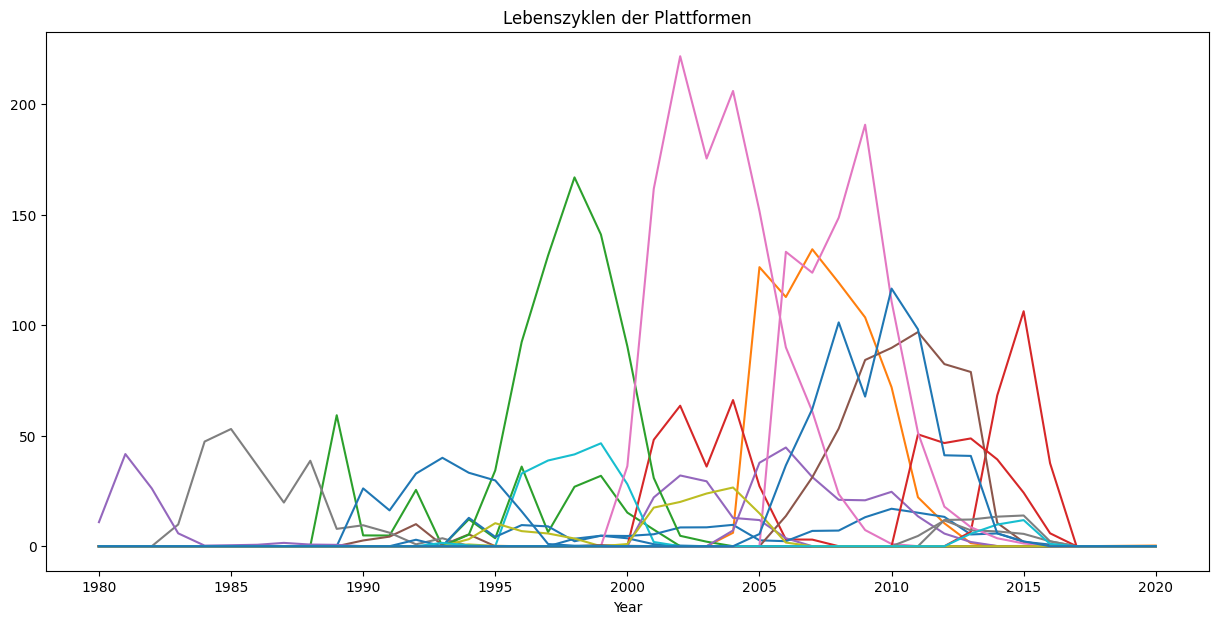

In [54]:
#Platform_Life_Cycle
platform_year = data.groupby(["Year","Platform"])["Global_Sales"].sum().unstack(fill_value=0)

platform_year.plot(figsize=(15,7), legend=False)
plt.title("Lebenszyklen der Plattformen")
plt.show()

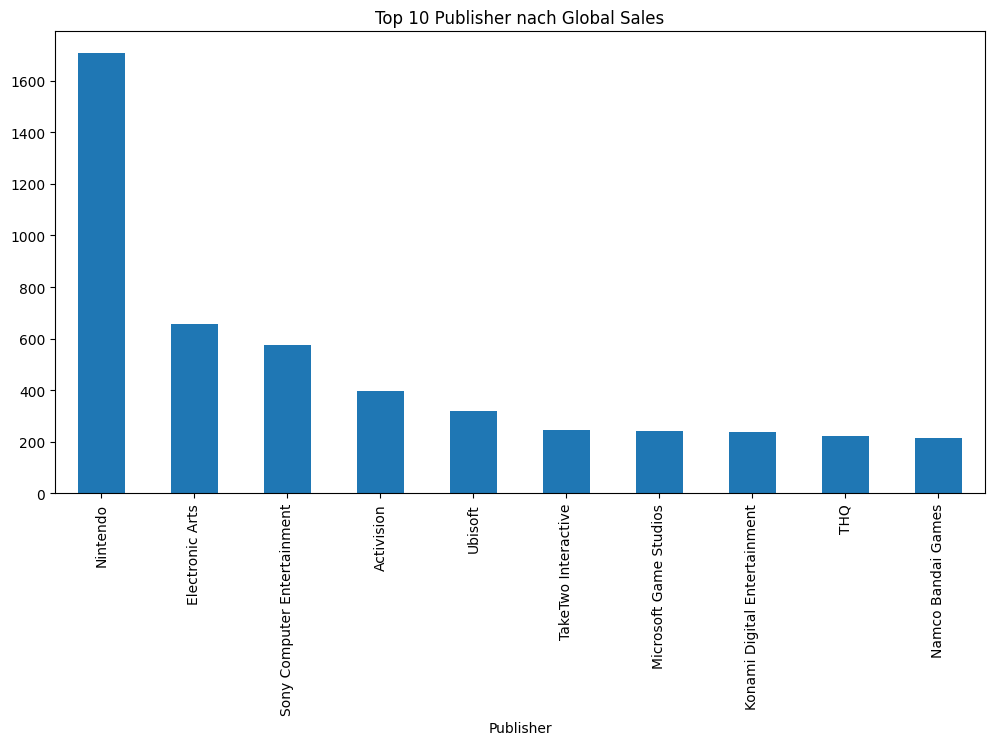

In [55]:
#Publisher (Top Publisher)
top_pub = data.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(10)

top_pub.plot(kind="bar", figsize=(12,6))
plt.title("Top 10 Publisher nach Global Sales")
plt.show()

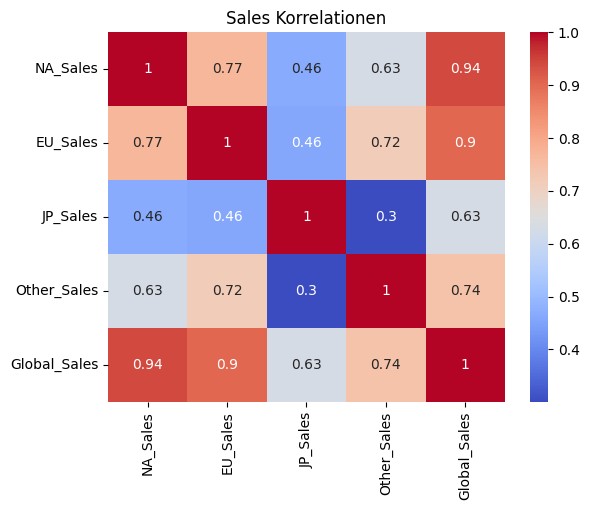

In [57]:
#Correlationsanalysis
import seaborn as sns

corr = data[["NA_Sales","EU_Sales","JP_Sales","Other_Sales","Global_Sales"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Sales Korrelationen")
plt.show()

In [58]:
#Plattform × Genre × Zeit (Pivot_Table_Preform)
pivot = data.groupby(["Year","Platform","Genre"]).size().reset_index(name="Count")

pivot

,Year,Platform,Genre,Count
0,1980,TowSixZeroZero,Action,1
1,1980,TowSixZeroZero,Fighting,1
2,1980,TowSixZeroZero,Misc,4
3,1980,TowSixZeroZero,Shooter,2
4,1981,TowSixZeroZero,Action,29
...,...,...,...,...
1592,2016,XOne,Simulation,1
1593,2016,XOne,Sports,1
1594,2017,PSFour,Role Playing,1
1595,2017,PSV,Action,1


In [59]:
#Plattform × Genre × Zeit (Pivot_Table_Better_View_Form)
pivot_table = pd.pivot_table(
    data,
    values="Global_Sales",
    index="Year",
    columns="Platform",
    aggfunc="sum",
    fill_value=0
)

pivot_table

Platform,DC,DS,GB,GBA,GC,GEN,GG,NES,NG,NSixFour,...,TGOneSix,ThreeDO,ThreeDS,TowSixZeroZero,WS,Wii,WiiU,XB,XOne,XThreeSixZero
Year,,,,,,,,,,,,,,,,,,,,,
1980,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,10.89,0.00,0.00,0.00,0.00,0.00,0.00
1981,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,41.69,0.00,0.00,0.00,0.00,0.00,0.00
1982,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,26.15,0.00,0.00,0.00,0.00,0.00,0.00
1983,0.00,0.00,0.00,0.00,0.00,0.00,0.00,9.83,0.00,0.00,...,0.00,0.00,0.00,5.83,0.00,0.00,0.00,0.00,0.00,0.00
1984,0.00,0.00,0.00,0.00,0.00,0.00,0.00,47.35,0.00,0.00,...,0.00,0.00,0.00,0.27,0.00,0.00,0.00,0.00,0.00,0.00
1985,0.00,0.02,0.00,0.00,0.00,0.00,0.00,53.03,0.00,0.00,...,0.00,0.00,0.00,0.45,0.00,0.00,0.00,0.00,0.00,0.00
1986,0.00,0.00,0.00,0.00,0.00,0.00,0.00,36.41,0.00,0.00,...,0.00,0.00,0.00,0.66,0.00,0.00,0.00,0.00,0.00,0.00
1987,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.76,0.00,0.00,...,0.00,0.00,0.00,1.51,0.00,0.00,0.00,0.00,0.00,0.00
1988,0.00,0.00,0.00,0.00,0.00,0.00,0.00,38.67,0.00,0.00,...,0.00,0.00,0.00,0.75,0.00,0.00,0.00,0.00,0.00,0.00


In [60]:
#Pivot_Table 20 rows
pivot_table.head(20)

Platform,DC,DS,GB,GBA,GC,GEN,GG,NES,NG,NSixFour,...,TGOneSix,ThreeDO,ThreeDS,TowSixZeroZero,WS,Wii,WiiU,XB,XOne,XThreeSixZero
Year,,,,,,,,,,,,,,,,,,,,,
1980,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,10.89,0.00,0.0,0.0,0.0,0.0,0.0
1981,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,41.69,0.00,0.0,0.0,0.0,0.0,0.0
1982,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,26.15,0.00,0.0,0.0,0.0,0.0,0.0
1983,0.00,0.00,0.00,0.0,0.0,0.00,0.00,9.83,0.00,0.00,...,0.00,0.00,0.0,5.83,0.00,0.0,0.0,0.0,0.0,0.0
1984,0.00,0.00,0.00,0.0,0.0,0.00,0.00,47.35,0.00,0.00,...,0.00,0.00,0.0,0.27,0.00,0.0,0.0,0.0,0.0,0.0
1985,0.00,0.02,0.00,0.0,0.0,0.00,0.00,53.03,0.00,0.00,...,0.00,0.00,0.0,0.45,0.00,0.0,0.0,0.0,0.0,0.0
1986,0.00,0.00,0.00,0.0,0.0,0.00,0.00,36.41,0.00,0.00,...,0.00,0.00,0.0,0.66,0.00,0.0,0.0,0.0,0.0,0.0
1987,0.00,0.00,0.00,0.0,0.0,0.00,0.00,19.76,0.00,0.00,...,0.00,0.00,0.0,1.51,0.00,0.0,0.0,0.0,0.0,0.0
1988,0.00,0.00,0.00,0.0,0.0,0.00,0.00,38.67,0.00,0.00,...,0.00,0.00,0.0,0.75,0.00,0.0,0.0,0.0,0.0,0.0


In [61]:
#Pivot Random 20
pivot_table.sample(20)

Platform,DC,DS,GB,GBA,GC,GEN,GG,NES,NG,NSixFour,...,TGOneSix,ThreeDO,ThreeDS,TowSixZeroZero,WS,Wii,WiiU,XB,XOne,XThreeSixZero
Year,,,,,,,,,,,,,,,,,,,,,
2009,0.00,103.51,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,0.0,0.0,0.00,0.00,0.00,190.67,0.00,0.00,0.00,67.69
2012,0.00,10.37,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,0.0,0.0,46.68,0.00,0.00,17.89,11.89,0.00,0.00,41.14
1993,0.00,0.00,0.00,0.00,0.00,0.50,0.0,3.61,0.14,0.00,...,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1997,0.00,0.00,6.37,0.00,0.00,0.00,0.0,0.00,0.00,38.78,...,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1998,3.39,0.00,26.90,0.00,0.00,0.00,0.0,0.00,0.00,41.54,...,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1989,0.00,0.00,59.26,0.00,0.00,0.00,0.0,7.85,0.00,0.00,...,0.0,0.0,0.00,0.62,0.00,0.00,0.00,0.00,0.00,0.00
2015,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,0.0,0.0,24.21,0.00,0.00,1.26,13.90,0.00,11.81,2.20
1990,0.00,0.00,4.89,0.00,0.00,2.60,0.0,9.49,0.00,0.00,...,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1986,0.00,0.00,0.00,0.00,0.00,0.00,0.0,36.41,0.00,0.00,...,0.0,0.0,0.00,0.66,0.00,0.00,0.00,0.00,0.00,0.00


In [62]:
#Pivot Sum_Sales
pivot_table.sum().sort_values(ascending=False)

Platform
PSTow             1135.44
Wii                789.67
DS                 708.26
PS                 699.34
XThreeSixZero      577.82
PSThree            542.68
GBA                247.13
GB                 234.11
NES                233.08
PSFour             218.61
ThreeDS            215.38
PSP                208.58
SNES               195.44
NSixFour           189.77
PC                 173.62
GC                 111.70
XB                 105.44
TowSixZeroZero      88.82
WiiU                53.46
PSV                 38.02
SAT                 29.67
XOne                28.34
GEN                 22.79
DC                  13.00
SCD                  1.87
NG                   1.11
WS                   0.66
TGOneSix             0.16
ThreeDO              0.10
GG                   0.04
PCFX                 0.03
dtype: float64

In [63]:
#Export to Excel
pivot_table.to_csv("pivot_platform_year.csv")

In [64]:
#Korrelationsmatrix

In [68]:
corr = data[["NA_Sales","EU_Sales","JP_Sales","Other_Sales","Global_Sales"]].corr()
corr.round(3)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
NA_Sales,1.000,0.770,0.465,0.629,0.941
EU_Sales,0.770,1.000,0.456,0.716,0.903
JP_Sales,0.465,0.456,1.000,0.301,0.630
Other_Sales,0.629,0.716,0.301,1.000,0.740
Global_Sales,0.941,0.903,0.630,0.740,1.000


In [71]:
#Gezielter r-Wert (data["Name einfügen"])
r = data["NA_Sales"].corr(data["Global_Sales"])
r

np.float64(0.9414092229180464)

In [ ]:
# r+p-Wert
from scipy.stats import pearsonr

r, p = pearsonr(data["NA_Sales"], data["Global_Sales"])

print (f"r = {r:.3f}")
print(f"p-Wert = {p:.6f}") 
# alle r-Werte gegen Global_Sales
Global_Sales = NA + EU + JP + Other

r = 0.941
p-Wert = 0.000000


In [ ]:
# Korrelation Year to Global_Sales
data[["Year","Global_Sales"]].corr()

,Year,Global_Sales
Year,1.000000,-0.077787
Global_Sales,-0.077787,1.000000


In [ ]:
data.groupby("Year")["Global_Sales"].sum().corr(data.groupby("Year")["Year"].mean())

np.float64(0.5167027127844571)